# BP vs FF on MNIST (2 layers): Scientific Comparison

This notebook builds a direct comparison between Backpropagation (BP) and Forward-Forward (FF) SNN training runs for neuron types:

- `lif`
- `alif`
- `srm`
- `dynsrm`

It automatically loads the latest run artifacts from each method and generates publication-style figures for:

1. Accuracy / Macro-F1 trajectories
2. Efficiency tradeoffs (speed, event ratio, memory)
3. Best-vs-final metrics by neuron type
4. Confusion matrices of best checkpoints

**Important path rule used here**

For FF results:
- `lif`, `alif` are loaded from regular `result/2layers/<model>/`
- `srm`, `dynsrm` are loaded from tuned folders:
  - `result/2layers/srm_tune/`
  - `result/2layers/dynsrm_tune/`


In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

NEURON_TYPES = ["lif", "alif", "srm", "dynsrm"]

BP_BASE = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers")
FF_BASE = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers")

OUT_DIR = BP_BASE / "visualizations_bp_ff"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def ff_model_dir(model: str) -> Path:
    if model == "srm":
        return FF_BASE / "srm_tune"
    if model == "dynsrm":
        return FF_BASE / "dynsrm_tune"
    return FF_BASE / model


def find_latest_csv(model_dir: Path, model: str, method_tag: str) -> Path:
    # Match only run csv files, exclude confusion / helper csvs.
    pat = re.compile(rf"^MNIST_{re.escape(model)}_{method_tag}_v2_\d{{8}}_\d{{6}}\.csv$")
    candidates = [p for p in model_dir.glob("*.csv") if pat.match(p.name)]
    if not candidates:
        raise FileNotFoundError(f"No run CSV found in {model_dir} for {model} {method_tag}")
    return sorted(candidates, key=lambda p: p.stat().st_mtime)[-1]


def resolve_path(value: str, csv_path: Path) -> Path:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return Path()
    p = Path(str(value))
    return p if p.is_absolute() else (csv_path.parent / p)


def load_one_run(model: str, method: str) -> dict:
    if method == "BP":
        model_dir = BP_BASE / model
        csv_path = find_latest_csv(model_dir, model, "BP")
    elif method == "FF":
        model_dir = ff_model_dir(model)
        csv_path = find_latest_csv(model_dir, model, "FF")
    else:
        raise ValueError(method)

    df = pd.read_csv(csv_path)
    if "epoch" in df.columns:
        df = df.sort_values("epoch").reset_index(drop=True)

    # Normalize names for side-by-side plotting.
    rename_map = {
        "train_speed": "train_speed_sps",
        "test_speed": "test_speed_sps",
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]

    # Keep best confusion matrix path from latest row if available.
    last = df.iloc[-1]
    best_conf = resolve_path(last.get("best_test_confusion_path", ""), csv_path)
    final_conf = resolve_path(last.get("final_test_confusion_path", ""), csv_path)

    return {
        "method": method,
        "model": model,
        "csv_path": csv_path,
        "data": df,
        "best_confusion_path": best_conf,
        "final_confusion_path": final_conf,
    }


runs = {}
for model in NEURON_TYPES:
    runs[("BP", model)] = load_one_run(model, "BP")
    runs[("FF", model)] = load_one_run(model, "FF")

rows = []
for (method, model), item in runs.items():
    df = item["data"].copy()
    df["method"] = method
    df["model"] = model
    rows.append(df)

all_df = pd.concat(rows, ignore_index=True)

print(f"Loaded {len(runs)} runs")
for (method, model), item in runs.items():
    print(f"{method:>2} | {model:<6} | {item['csv_path']}")

print(f"\nCombined table shape: {all_df.shape}")
print(f"Figures will be saved to: {OUT_DIR}")

Loaded 8 runs
BP | lif    | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/lif/MNIST_lif_BP_v2_20260408_003530.csv
FF | lif    | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/lif/MNIST_lif_FF_v2_20260324_113036.csv
BP | alif   | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/alif/MNIST_alif_BP_v2_20260408_003712.csv
FF | alif   | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/alif/MNIST_alif_FF_v2_20260324_113459.csv
BP | srm    | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/srm/MNIST_srm_BP_v2_20260408_003805.csv
FF | srm    | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/srm_tune/MNIST_srm_FF_v2_20260407_225515.csv
BP | dynsrm | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/dynsrm/MNIST_dynsrm_BP_v2_20260408_003907.csv
FF | dynsrm 

In [2]:
def get_last_value(df: pd.DataFrame, key: str, default=np.nan):
    return df[key].iloc[-1] if key in df.columns and len(df) > 0 else default


def get_best_value(df: pd.DataFrame, key: str, default=np.nan):
    return df[key].max() if key in df.columns and len(df) > 0 else default


summary_rows = []
for (method, model), item in runs.items():
    df = item["data"]
    summary_rows.append(
        {
            "method": method,
            "model": model,
            "epochs": int(df["epoch"].max()) if "epoch" in df.columns else len(df),
            "best_test_acc": get_best_value(df, "test_acc"),
            "best_test_macro_f1": get_best_value(df, "test_macro_f1"),
            "final_test_acc": get_last_value(df, "test_acc"),
            "final_test_macro_f1": get_last_value(df, "test_macro_f1"),
            "final_test_speed_sps": get_last_value(df, "test_speed_sps", get_last_value(df, "test_speed")),
            "final_test_latency_ms": get_last_value(df, "test_latency_ms_per_sample"),
            "final_test_event_ratio": get_last_value(df, "test_event_to_dense_ratio"),
            "final_test_cpu_mb": get_last_value(df, "test_cpu_memory_mb"),
            "final_test_gpu_alloc_mb": get_last_value(df, "test_gpu_memory_allocated_mb"),
            "csv_path": str(item["csv_path"]),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(["model", "method"]).reset_index(drop=True)
summary_path = OUT_DIR / "bp_ff_summary_table.csv"
summary_df.to_csv(summary_path, index=False)

summary_df

,method,model,epochs,best_test_acc,best_test_macro_f1,final_test_acc,final_test_macro_f1,final_test_speed_sps,final_test_latency_ms,final_test_event_ratio,final_test_cpu_mb,final_test_gpu_alloc_mb,csv_path
0,BP,alif,100,0.9828,0.982652,0.9800,0.979908,2234.661564,0.447495,0.192661,1461.578125,127.020020,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,FF,alif,100,0.9757,0.975487,0.9738,0.973602,4673.280168,0.213982,0.119194,1479.613281,418.994141,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,BP,dynsrm,100,0.9849,0.984759,0.9845,0.984386,2083.819204,0.479888,0.192808,1444.234375,127.025879,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,FF,dynsrm,300,0.9767,0.976542,0.9751,0.974902,1414.361875,0.707033,0.123944,1496.632812,840.269043,/home/yhxu/spikingjelly/spikingjelly/spikingje...
4,BP,lif,100,0.9805,0.980323,0.9773,0.977188,1856.789405,0.538564,0.192490,1453.429688,127.016113,/home/yhxu/spikingjelly/spikingjelly/spikingje...
5,FF,lif,100,0.9731,0.972807,0.9710,0.970660,2866.010662,0.348917,0.119035,1482.597656,421.226562,/home/yhxu/spikingjelly/spikingjelly/spikingje...
6,BP,srm,100,0.9836,0.983505,0.9827,0.982524,2710.472587,0.368939,0.192840,1410.820312,127.016113,/home/yhxu/spikingjelly/spikingjelly/spikingje...
7,FF,srm,300,0.9767,0.976542,0.9751,0.974902,1231.914036,0.811745,0.123944,1493.121094,840.253418,/home/yhxu/spikingjelly/spikingjelly/spikingje...


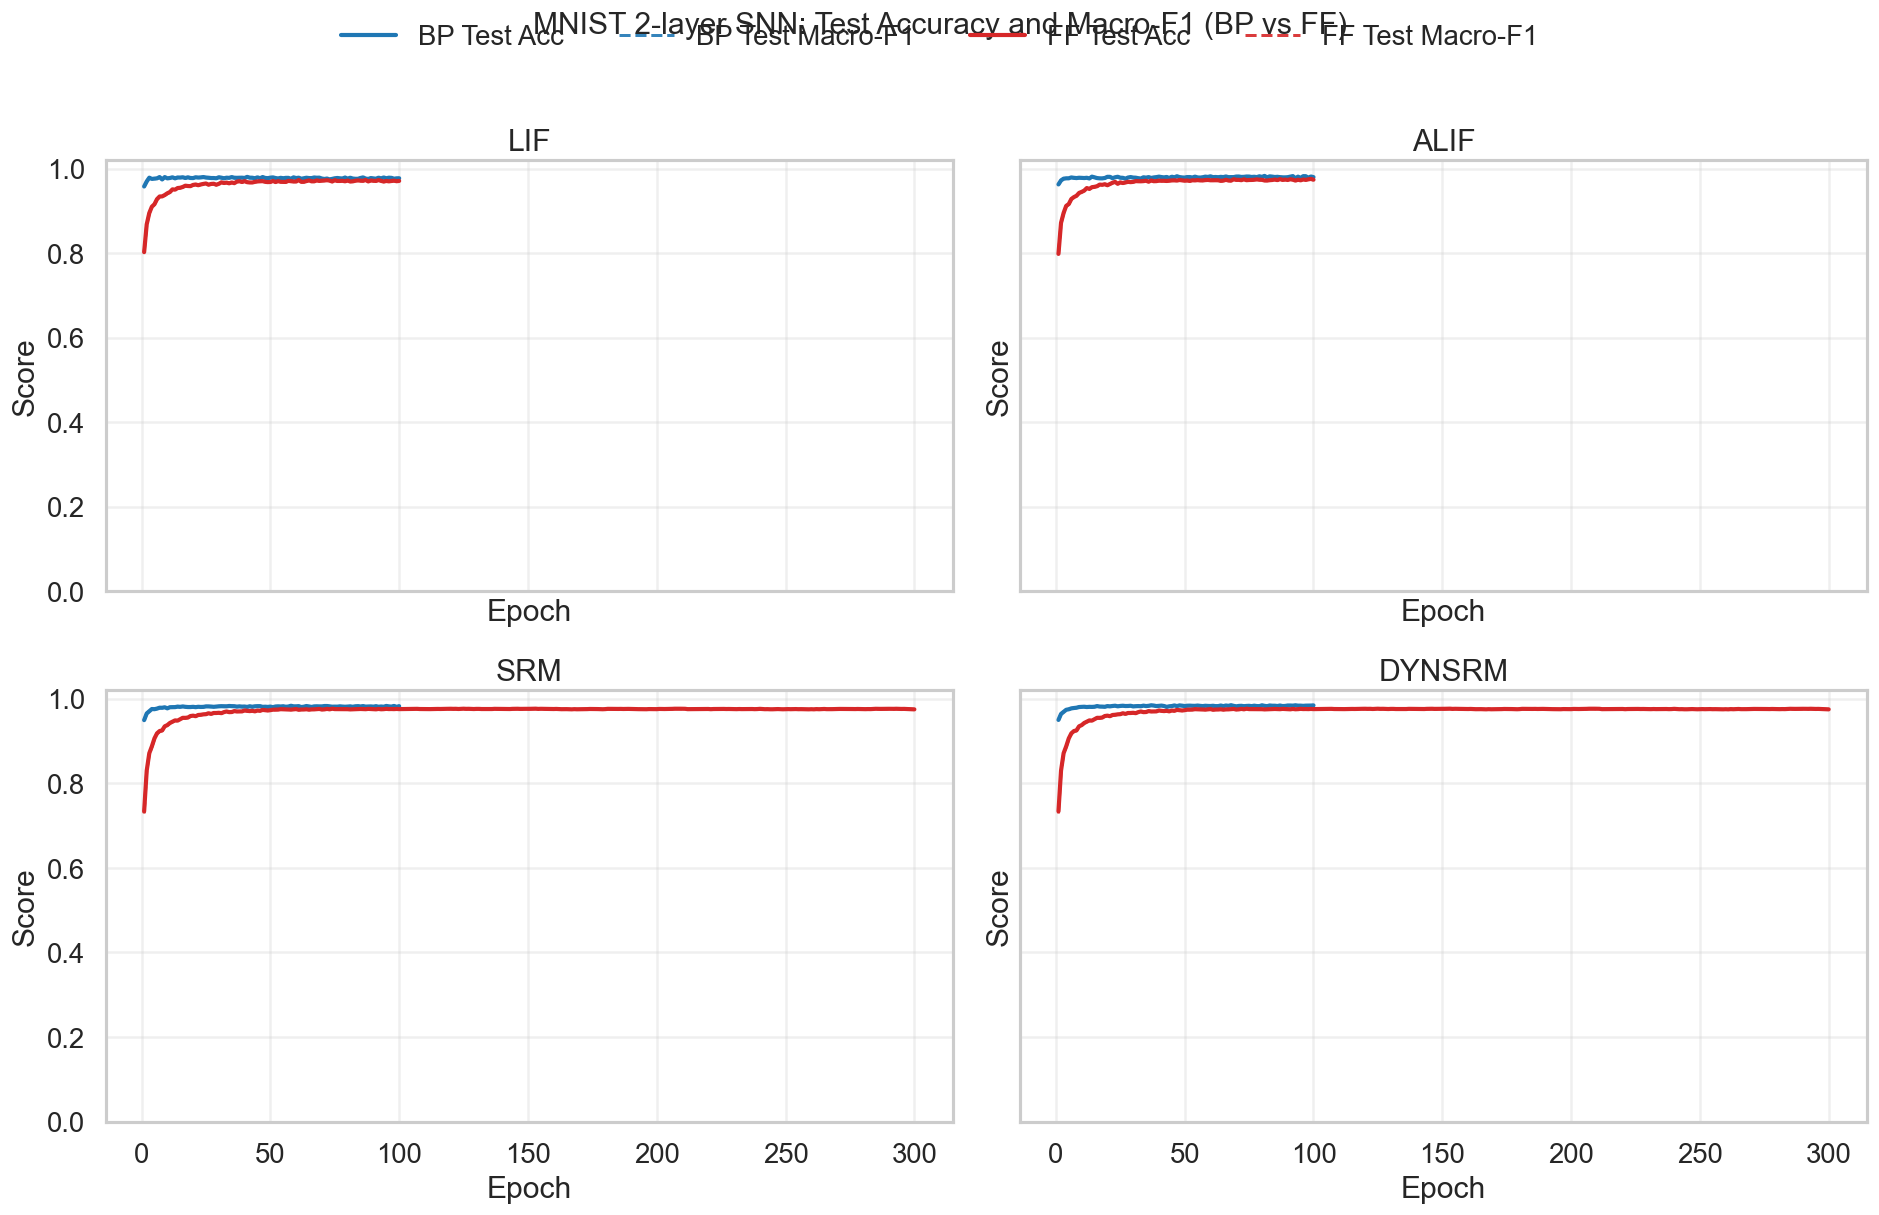

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_accuracy_f1_curves.png


In [5]:
palette = {"BP": "#1f77b4", "FF": "#d62728"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, model in enumerate(NEURON_TYPES):
    ax = axes[i]
    for method in ["BP", "FF"]:
        df = runs[(method, model)]["data"]
        ax.plot(df["epoch"], df["test_acc"], label=f"{method} Test Acc", color=palette[method], linewidth=2.5)
        if "test_macro_f1" in df.columns:
            ax.plot(
                df["epoch"],
                df["test_macro_f1"],
                label=f"{method} Test Macro-F1",
                color=palette[method],
                linewidth=1.8,
                linestyle="--",
                alpha=0.9,
            )
    ax.set_title(model.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
fig.suptitle("MNIST 2-layer SNN: Test Accuracy and Macro-F1 (BP vs FF)", y=1.02, fontsize=18)
fig.tight_layout()

curve_path = OUT_DIR / "bp_ff_accuracy_f1_curves.png"
fig.savefig(curve_path, bbox_inches="tight")
plt.show()

print("Saved:", curve_path)

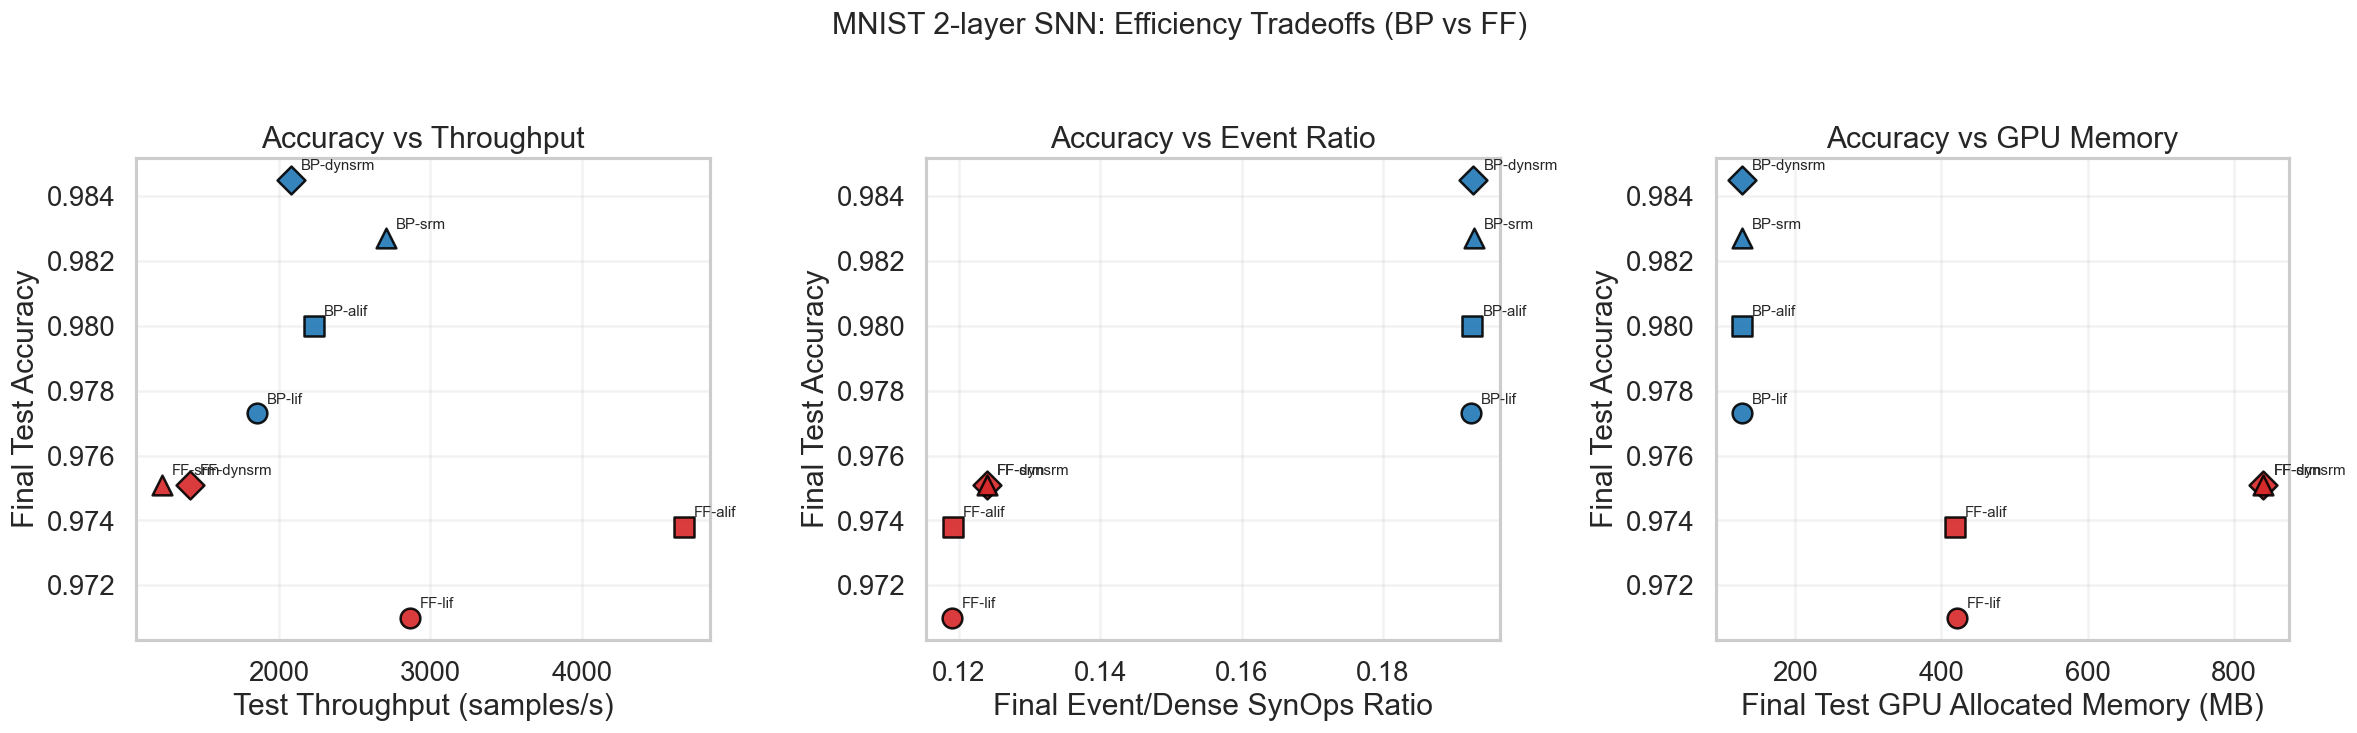

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_efficiency_tradeoffs.png


In [6]:
end_df = summary_df.copy()

marker_map = {"lif": "o", "alif": "s", "srm": "^", "dynsrm": "D"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Accuracy vs speed
ax = axes[0]
for _, r in end_df.iterrows():
    ax.scatter(
        r["final_test_speed_sps"],
        r["final_test_acc"],
        s=140,
        color=palette[r["method"]],
        marker=marker_map[r["model"]],
        edgecolor="black",
        alpha=0.9,
    )
    ax.annotate(f"{r['method']}-{r['model']}", (r["final_test_speed_sps"], r["final_test_acc"]), fontsize=9, xytext=(6, 6), textcoords="offset points")
ax.set_xlabel("Test Throughput (samples/s)")
ax.set_ylabel("Final Test Accuracy")
ax.set_title("Accuracy vs Throughput")

# (b) Accuracy vs event-to-dense ratio
ax = axes[1]
for _, r in end_df.iterrows():
    ax.scatter(
        r["final_test_event_ratio"],
        r["final_test_acc"],
        s=140,
        color=palette[r["method"]],
        marker=marker_map[r["model"]],
        edgecolor="black",
        alpha=0.9,
    )
    ax.annotate(f"{r['method']}-{r['model']}", (r["final_test_event_ratio"], r["final_test_acc"]), fontsize=9, xytext=(6, 6), textcoords="offset points")
ax.set_xlabel("Final Event/Dense SynOps Ratio")
ax.set_ylabel("Final Test Accuracy")
ax.set_title("Accuracy vs Event Ratio")

# (c) Accuracy vs GPU memory
ax = axes[2]
for _, r in end_df.iterrows():
    ax.scatter(
        r["final_test_gpu_alloc_mb"],
        r["final_test_acc"],
        s=140,
        color=palette[r["method"]],
        marker=marker_map[r["model"]],
        edgecolor="black",
        alpha=0.9,
    )
    ax.annotate(f"{r['method']}-{r['model']}", (r["final_test_gpu_alloc_mb"], r["final_test_acc"]), fontsize=9, xytext=(6, 6), textcoords="offset points")
ax.set_xlabel("Final Test GPU Allocated Memory (MB)")
ax.set_ylabel("Final Test Accuracy")
ax.set_title("Accuracy vs GPU Memory")

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.suptitle("MNIST 2-layer SNN: Efficiency Tradeoffs (BP vs FF)", y=1.03, fontsize=18)
fig.tight_layout()

tradeoff_path = OUT_DIR / "bp_ff_efficiency_tradeoffs.png"
fig.savefig(tradeoff_path, bbox_inches="tight")
plt.show()

print("Saved:", tradeoff_path)

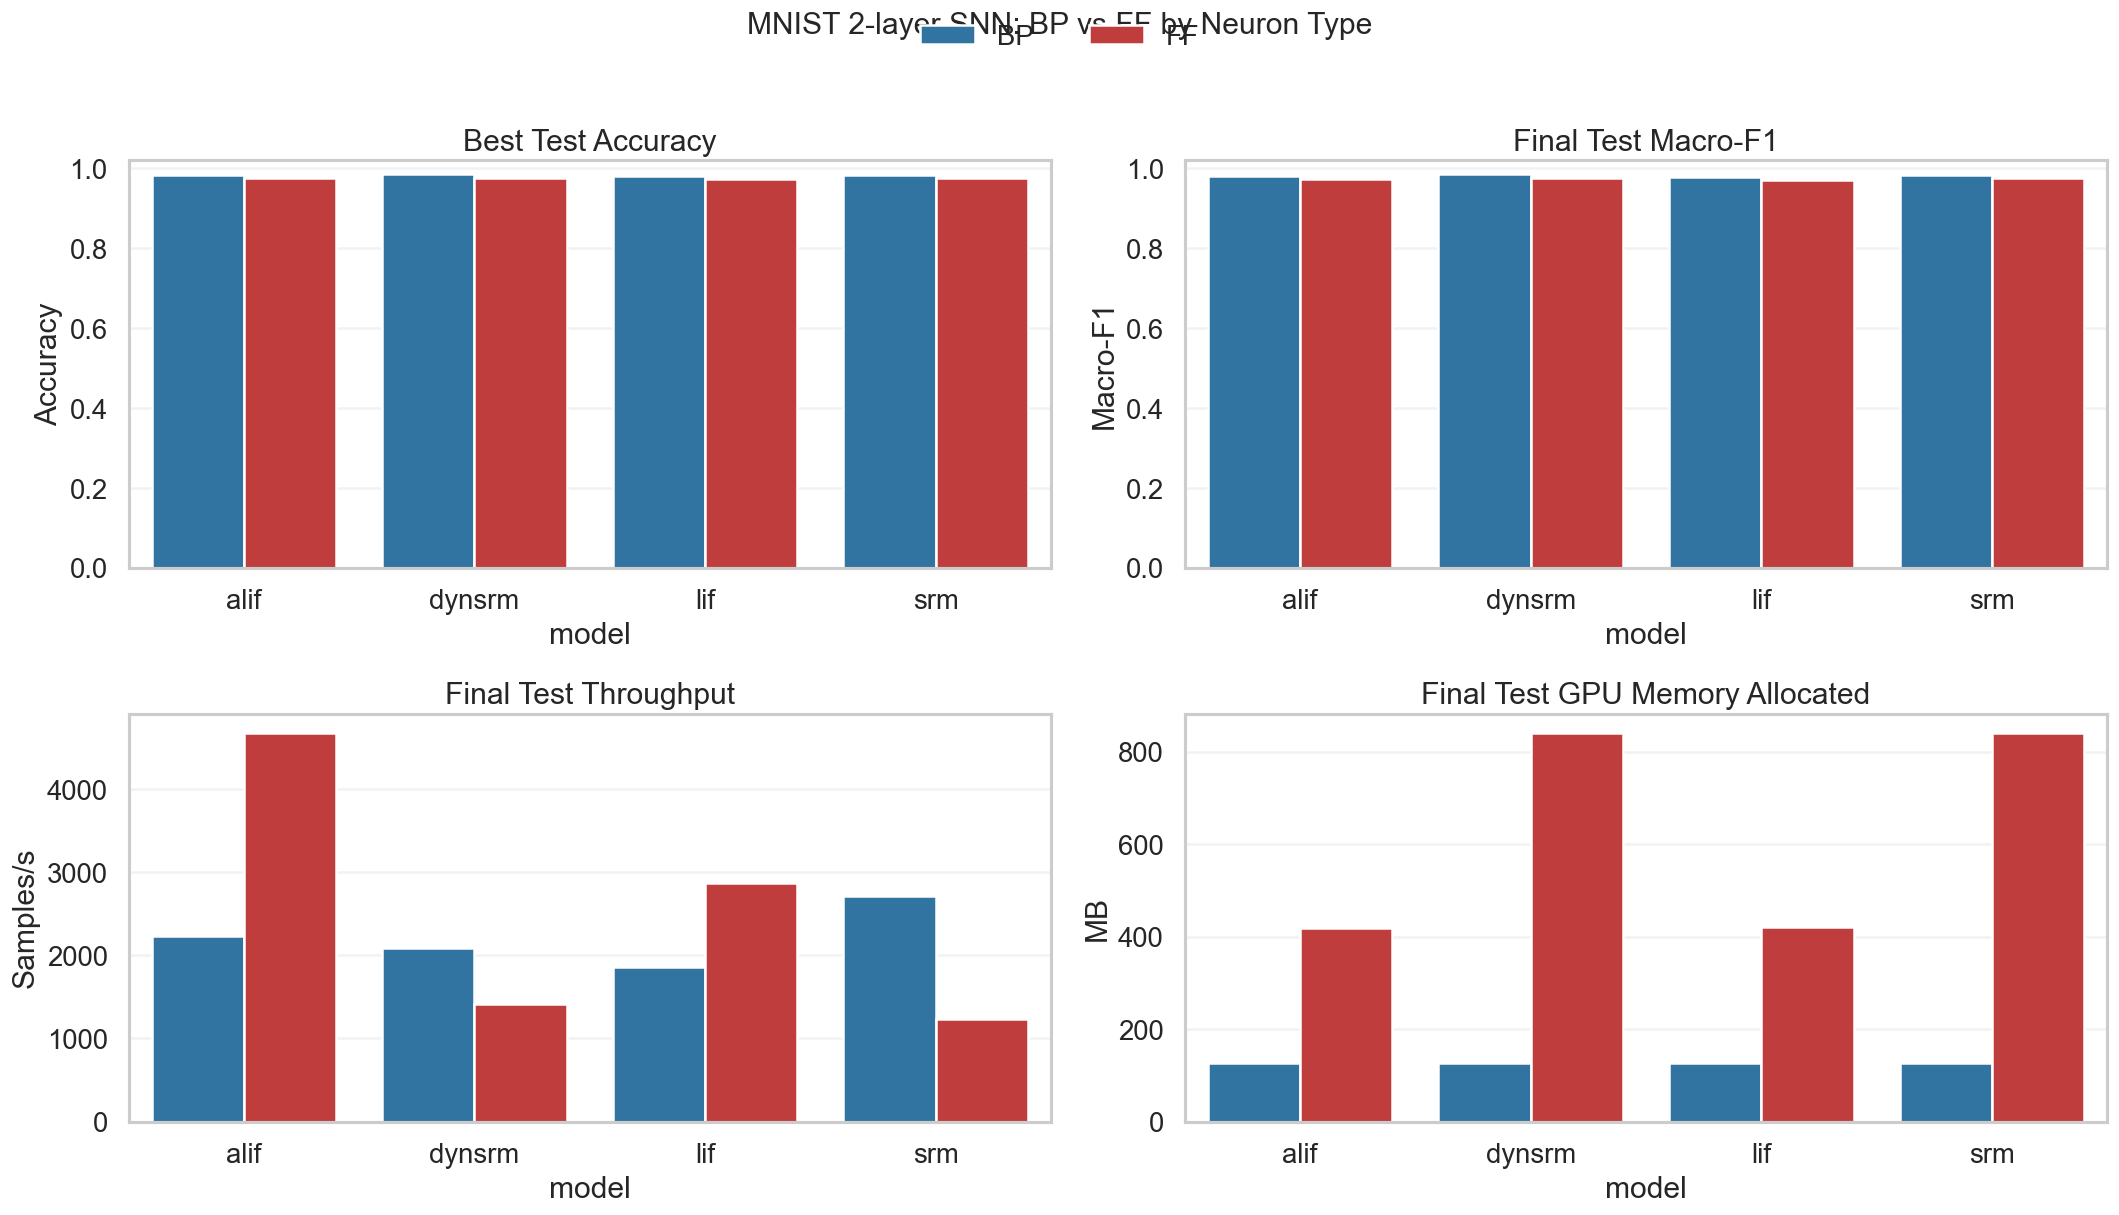

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_grouped_bars.png


In [5]:
plot_df = summary_df.copy()
plot_df["model_method"] = plot_df["model"].str.upper() + "-" + plot_df["method"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=plot_df, x="model", y="best_test_acc", hue="method", palette=palette, ax=axes[0, 0])
axes[0, 0].set_title("Best Test Accuracy")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0.0, 1.02)

sns.barplot(data=plot_df, x="model", y="final_test_macro_f1", hue="method", palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("Final Test Macro-F1")
axes[0, 1].set_ylabel("Macro-F1")
axes[0, 1].set_ylim(0.0, 1.02)

sns.barplot(data=plot_df, x="model", y="final_test_speed_sps", hue="method", palette=palette, ax=axes[1, 0])
axes[1, 0].set_title("Final Test Throughput")
axes[1, 0].set_ylabel("Samples/s")

sns.barplot(data=plot_df, x="model", y="final_test_gpu_alloc_mb", hue="method", palette=palette, ax=axes[1, 1])
axes[1, 1].set_title("Final Test GPU Memory Allocated")
axes[1, 1].set_ylabel("MB")

for ax in axes.ravel():
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend_.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("MNIST 2-layer SNN: BP vs FF by Neuron Type", y=1.02, fontsize=18)
fig.tight_layout()

bar_path = OUT_DIR / "bp_ff_grouped_bars.png"
fig.savefig(bar_path, bbox_inches="tight")
plt.show()

print("Saved:", bar_path)

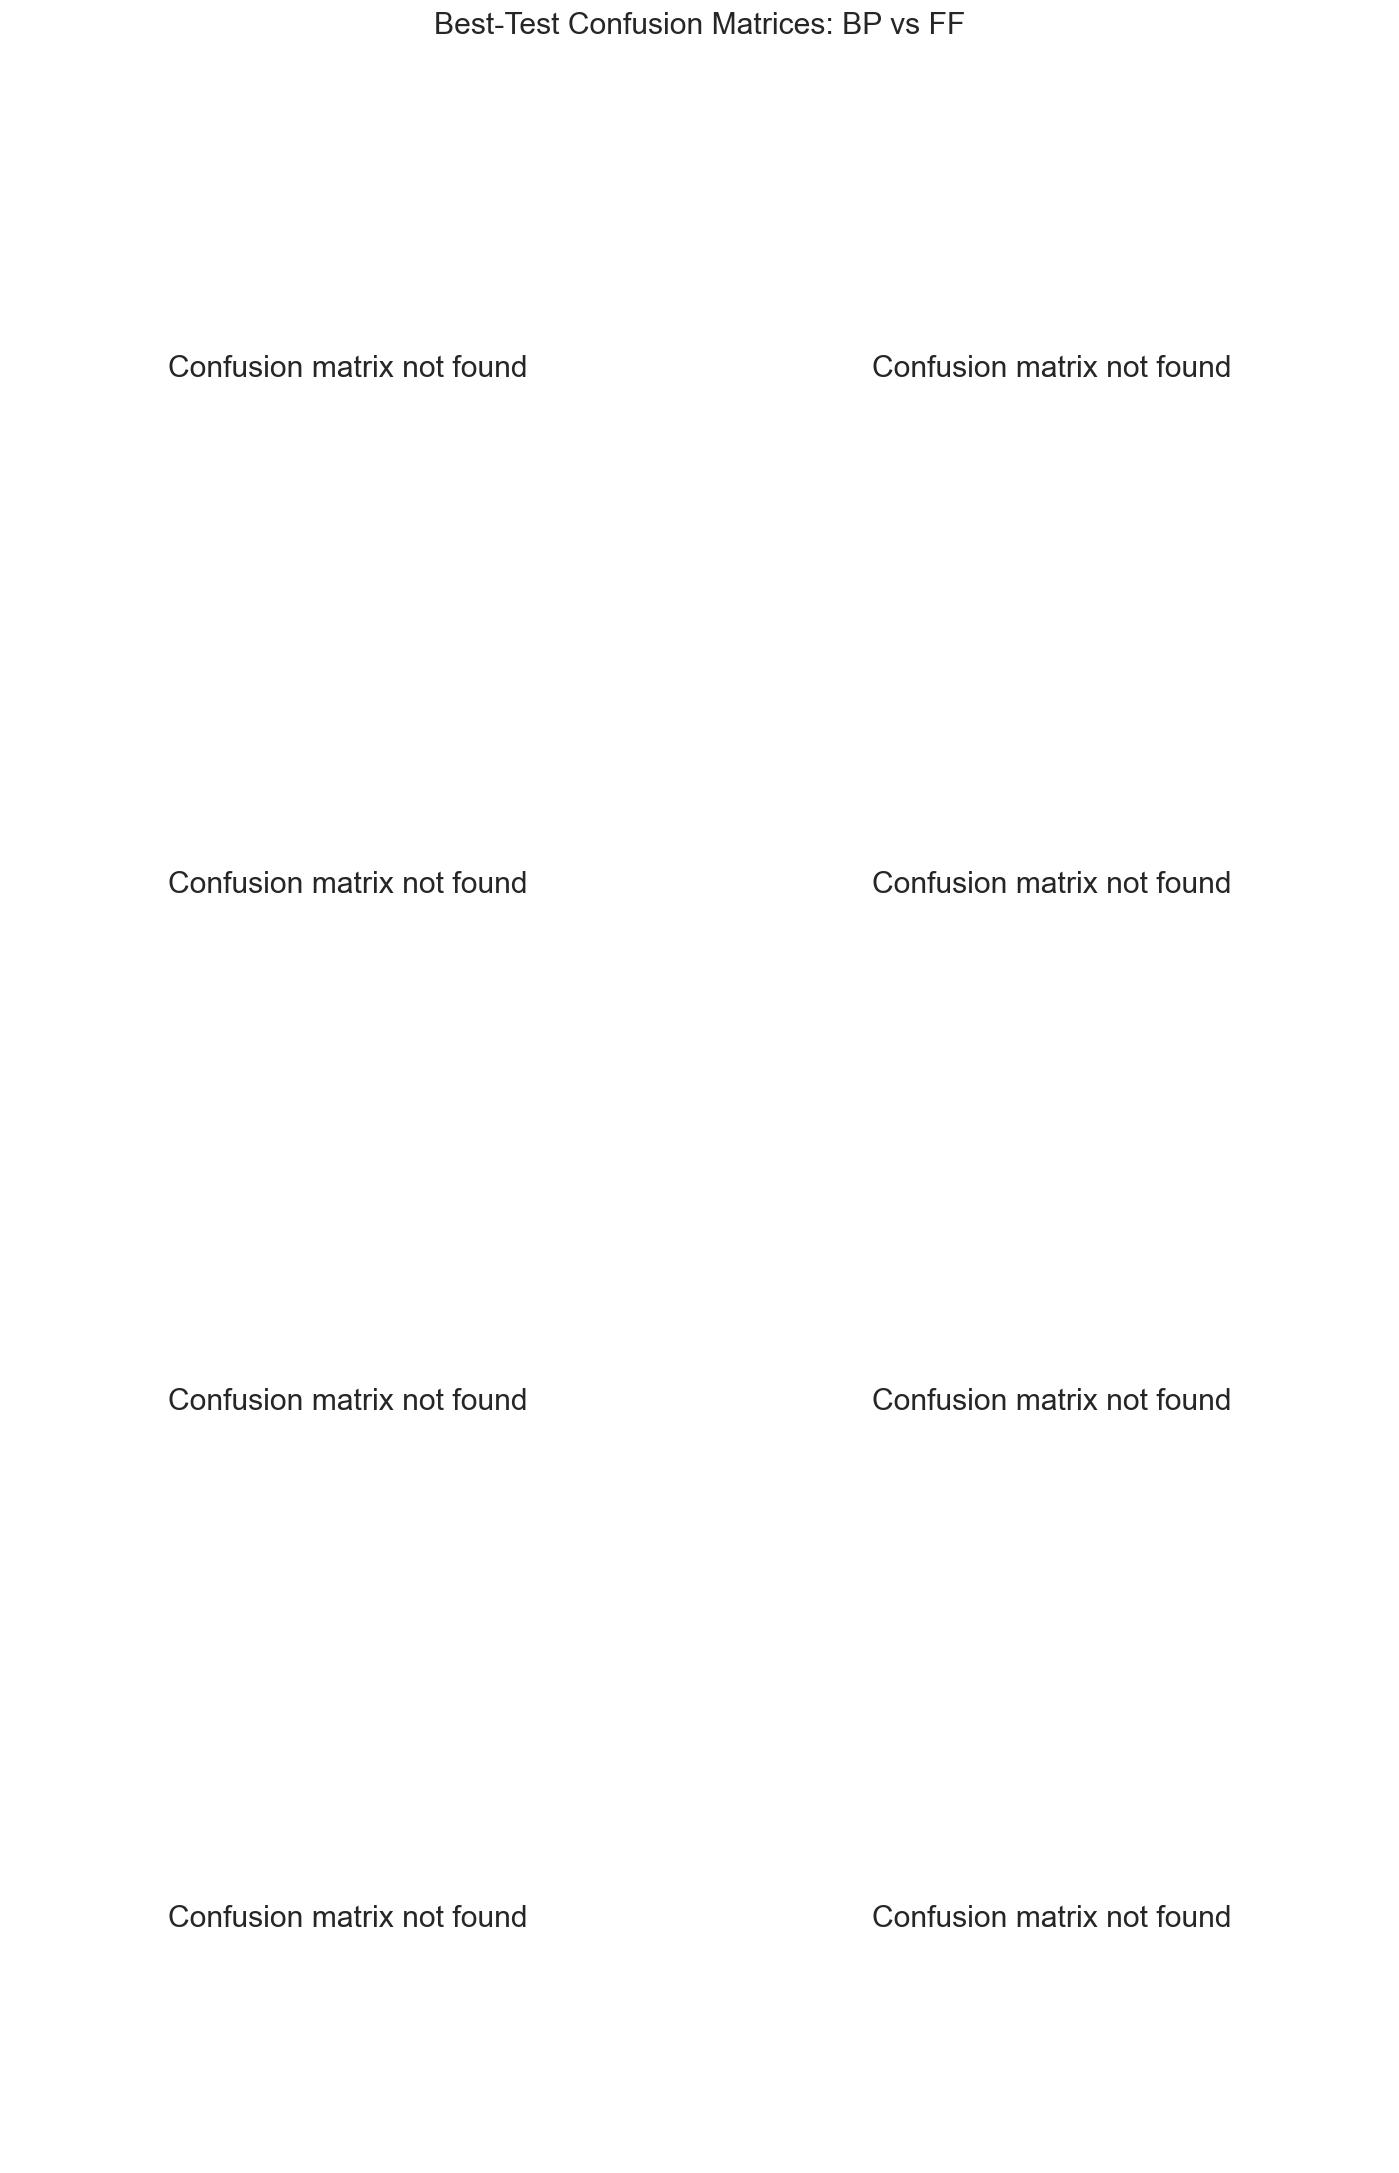

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_confusion_matrices.png


In [6]:
def read_confusion(path: Path) -> pd.DataFrame:
    if not path or not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path, index_col=0)
    # Ensure numeric matrix.
    return df.apply(pd.to_numeric, errors="coerce")


fig, axes = plt.subplots(len(NEURON_TYPES), 2, figsize=(12, 18))

for i, model in enumerate(NEURON_TYPES):
    for j, method in enumerate(["BP", "FF"]):
        ax = axes[i, j]
        info = runs[(method, model)]
        cm = read_confusion(info["best_confusion_path"])
        if cm.empty:
            ax.text(0.5, 0.5, "Confusion matrix not found", ha="center", va="center")
            ax.set_axis_off()
            continue
        sns.heatmap(
            cm,
            cmap="mako",
            cbar=(j == 1),
            square=True,
            xticklabels=False,
            yticklabels=False,
            ax=ax,
        )
        ax.set_title(f"{model.upper()} - {method}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

fig.suptitle("Best-Test Confusion Matrices: BP vs FF", y=1.01, fontsize=18)
fig.tight_layout()

cm_path = OUT_DIR / "bp_ff_confusion_matrices.png"
fig.savefig(cm_path, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [7]:
pivot_best = summary_df.pivot(index="model", columns="method", values="best_test_acc")
pivot_speed = summary_df.pivot(index="model", columns="method", values="final_test_speed_sps")
pivot_ratio = summary_df.pivot(index="model", columns="method", values="final_test_event_ratio")

comparison = pd.DataFrame(index=NEURON_TYPES)
comparison["delta_best_acc_FF_minus_BP"] = pivot_best["FF"] - pivot_best["BP"]
comparison["delta_speed_FF_minus_BP"] = pivot_speed["FF"] - pivot_speed["BP"]
comparison["delta_event_ratio_FF_minus_BP"] = pivot_ratio["FF"] - pivot_ratio["BP"]

comparison_path = OUT_DIR / "bp_ff_delta_table.csv"
comparison.to_csv(comparison_path, index=True)

print("Saved:", summary_path)
print("Saved:", comparison_path)
comparison

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_summary_table.csv
Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_delta_table.csv


,delta_best_acc_FF_minus_BP,delta_speed_FF_minus_BP,delta_event_ratio_FF_minus_BP
lif,-0.0074,1009.221257,-0.073456
alif,-0.0071,2438.618603,-0.073467
srm,-0.0069,-1478.558551,-0.068896
dynsrm,-0.0082,-669.457329,-0.068864


/tmp/ipykernel_3020852/391819540.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["LIF", "ALIF", "SRM", "DynamicSRM"], fontsize=12)


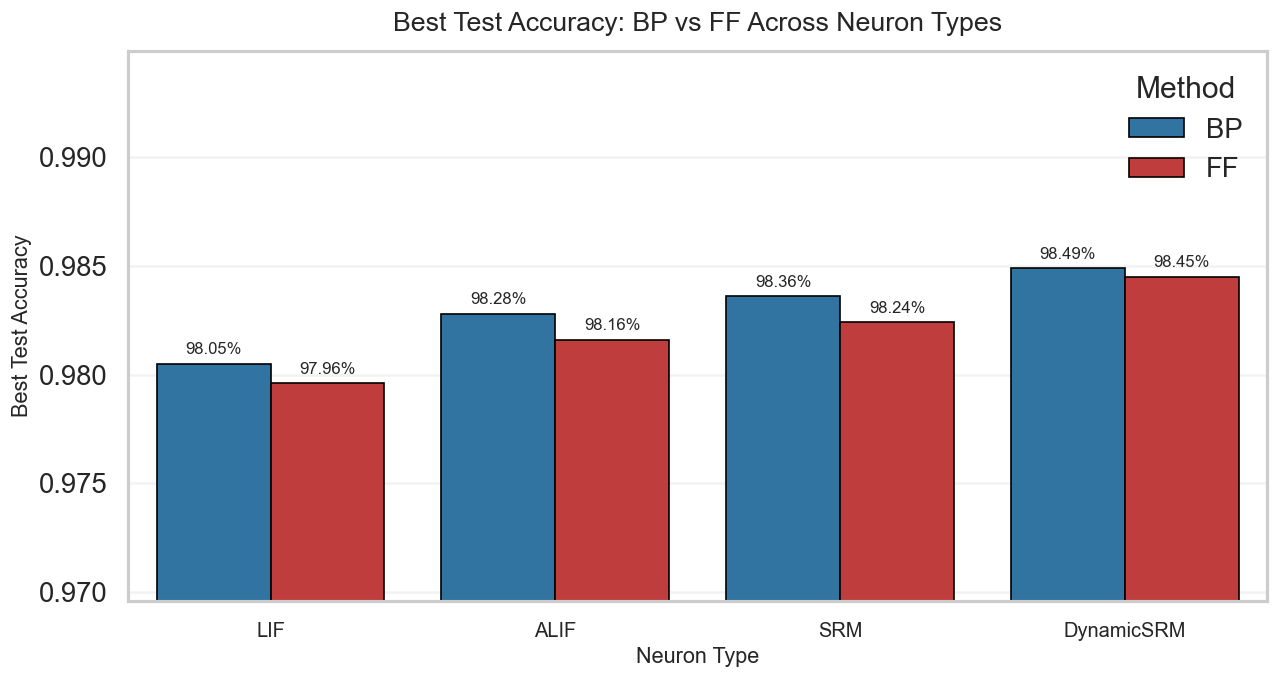

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_best_test_accuracy_clear_bar.png
Current accuracy table used for plotting:


,model,method,best_test_acc
0,lif,BP,0.9805
1,lif,FF,0.9796
2,alif,BP,0.9828
3,alif,FF,0.9816
4,srm,BP,0.9836
5,srm,FF,0.9824
6,dynsrm,BP,0.9849
7,dynsrm,FF,0.9845


In [7]:
# Clear grouped bar chart: BP vs FF test accuracy by neuron type
# ------------------------------------------------------------------
# You can edit the numbers below directly.
# Values are fractions in [0, 1], e.g. 0.9812 means 98.12%.
MANUAL_ACC = {
    "lif": {"BP": None, "FF": 0.9796},
    "alif": {"BP": None, "FF": 0.9816},
    "srm": {"BP": None, "FF": 0.9824},
    "dynsrm": {"BP": None, "FF": 0.9845},
}
# ------------------------------------------------------------------

# Start from computed values, then overwrite with MANUAL_ACC when provided.
acc_plot = summary_df[["model", "method", "best_test_acc"]].copy()
for model, method_vals in MANUAL_ACC.items():
    for method, val in method_vals.items():
        if val is not None:
            mask = (acc_plot["model"] == model) & (acc_plot["method"] == method)
            acc_plot.loc[mask, "best_test_acc"] = float(val)

acc_plot["model"] = pd.Categorical(acc_plot["model"], categories=["lif", "alif", "srm", "dynsrm"], ordered=True)
acc_plot = acc_plot.sort_values(["model", "method"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=acc_plot,
    x="model",
    y="best_test_acc",
    hue="method",
    order=["lif", "alif", "srm", "dynsrm"],
    hue_order=["BP", "FF"],
    palette={"BP": "#1f77b4", "FF": "#d62728"},
    edgecolor="black",
    linewidth=1.0,
    ax=ax,
)

# Add value labels on top of bars
for p in ax.patches:
    h = p.get_height()
    if np.isfinite(h):
        ax.annotate(f"{h*100:.2f}%", (p.get_x() + p.get_width() / 2.0, h),
                    ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

ax.set_title("Best Test Accuracy: BP vs FF Across Neuron Types", fontsize=16, pad=12)
ax.set_xlabel("Neuron Type", fontsize=13)
ax.set_ylabel("Best Test Accuracy", fontsize=13)
# Start y-axis near the data range to better reveal small differences.
y_min = float(acc_plot["best_test_acc"].min())
y_max = float(acc_plot["best_test_acc"].max())
ax.set_ylim(max(0.0, y_min - 0.01), min(1.02, y_max + 0.01))
ax.set_xticklabels(["LIF", "ALIF", "SRM", "DynamicSRM"], fontsize=12)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Method", frameon=False, loc="upper right")

fig.tight_layout()
acc_bar_path = OUT_DIR / "bp_ff_best_test_accuracy_clear_bar.png"
fig.savefig(acc_bar_path, bbox_inches="tight")
plt.show()

print("Saved:", acc_bar_path)
print("Current accuracy table used for plotting:")
acc_plot

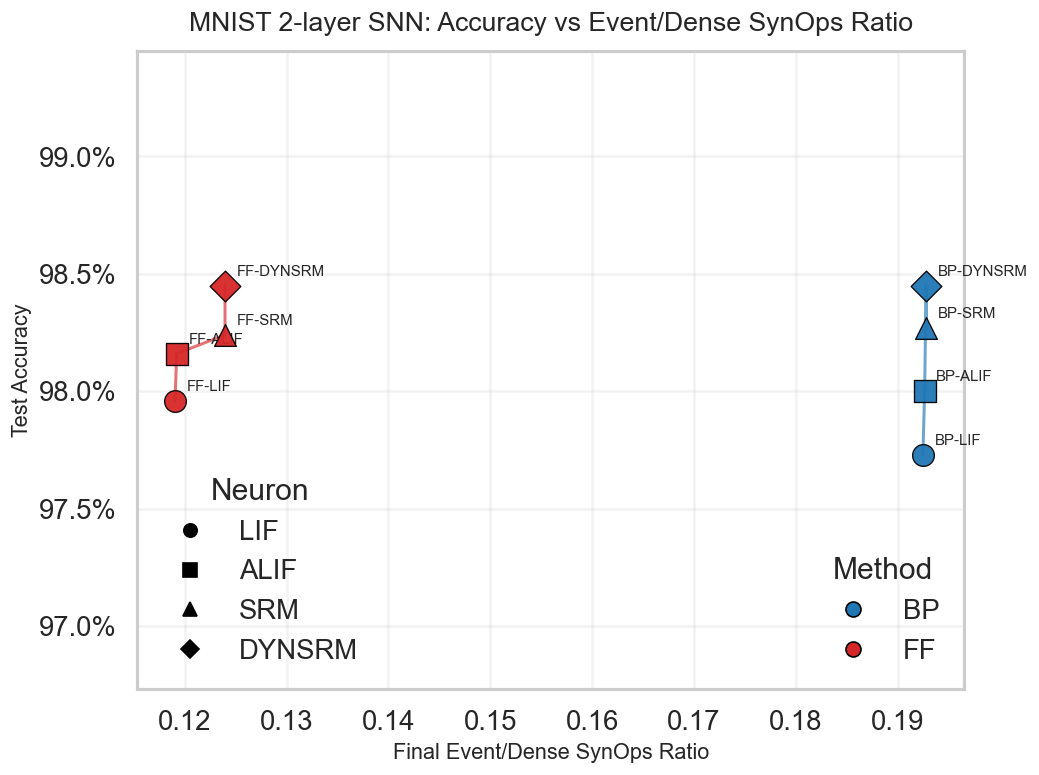

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_accuracy_vs_event_ratio_scientific.png
Accuracy values used in this figure:


,method,model,plot_test_acc,final_test_event_ratio
0,BP,lif,0.9773,0.192490
1,BP,alif,0.9800,0.192661
2,BP,srm,0.9827,0.192840
3,BP,dynsrm,0.9845,0.192808
4,FF,lif,0.9796,0.119035
5,FF,alif,0.9816,0.119194
6,FF,srm,0.9824,0.123944
7,FF,dynsrm,0.9845,0.123944


In [8]:
# Scientific re-plot: Test Accuracy vs Final Event/Dense SynOps Ratio
# Uses MANUAL_ACC overrides from the previous cell when provided.

plot_df = summary_df.copy()

# Build override map from MANUAL_ACC if it exists.
override_acc = {}
if "MANUAL_ACC" in globals():
    for model, method_vals in MANUAL_ACC.items():
        for method, val in method_vals.items():
            if val is not None:
                override_acc[(method, model)] = float(val)

# Default: use final_test_acc, then override with manual values.
plot_df["plot_test_acc"] = plot_df["final_test_acc"].astype(float)
for idx, row in plot_df.iterrows():
    key = (row["method"], row["model"])
    if key in override_acc:
        plot_df.at[idx, "plot_test_acc"] = override_acc[key]

plot_df["model"] = pd.Categorical(plot_df["model"], categories=["lif", "alif", "srm", "dynsrm"], ordered=True)
plot_df = plot_df.sort_values(["method", "model"]).reset_index(drop=True)

marker_map = {"lif": "o", "alif": "s", "srm": "^", "dynsrm": "D"}
color_map = {"BP": "#1f77b4", "FF": "#d62728"}

fig, ax = plt.subplots(figsize=(9, 6.8))

for _, r in plot_df.iterrows():
    ax.scatter(
        r["final_test_event_ratio"],
        r["plot_test_acc"],
        s=170,
        color=color_map[r["method"]],
        marker=marker_map[r["model"]],
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95,
        zorder=3,
    )
    ax.annotate(
        f"{r['method']}-{r['model'].upper()}",
        (r["final_test_event_ratio"], r["plot_test_acc"]),
        fontsize=9,
        xytext=(7, 6),
        textcoords="offset points",
    )

# Add light method-wise trend lines for readability.
for method in ["BP", "FF"]:
    d = plot_df[plot_df["method"] == method].dropna(subset=["final_test_event_ratio", "plot_test_acc"])
    if len(d) >= 2:
        x = d["final_test_event_ratio"].to_numpy(dtype=float)
        y = d["plot_test_acc"].to_numpy(dtype=float)
        order = np.argsort(x)
        x, y = x[order], y[order]
        ax.plot(x, y, color=color_map[method], linewidth=1.8, alpha=0.65, zorder=2)

ax.set_title("MNIST 2-layer SNN: Accuracy vs Event/Dense SynOps Ratio", fontsize=16, pad=12)
ax.set_xlabel("Final Event/Dense SynOps Ratio", fontsize=13)
ax.set_ylabel("Test Accuracy", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))

# Zoom y-axis for better visual separation.
y_min = float(plot_df["plot_test_acc"].min())
y_max = float(plot_df["plot_test_acc"].max())
ax.set_ylim(max(0.0, y_min - 0.01), min(1.02, y_max + 0.01))

ax.grid(True, alpha=0.25)

# Custom legend (method color + model marker)
method_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[m], markeredgecolor="black", markersize=9, label=m)
    for m in ["BP", "FF"]
]
model_handles = [
    plt.Line2D([0], [0], marker=marker_map[m], color="black", linestyle="None", markersize=8, label=m.upper())
    for m in ["lif", "alif", "srm", "dynsrm"]
]
leg1 = ax.legend(handles=method_handles, title="Method", loc="lower right", frameon=False)
ax.add_artist(leg1)
ax.legend(handles=model_handles, title="Neuron", loc="lower left", frameon=False)

fig.tight_layout()
ratio_path = OUT_DIR / "bp_ff_accuracy_vs_event_ratio_scientific.png"
fig.savefig(ratio_path, bbox_inches="tight")
plt.show()

print("Saved:", ratio_path)
print("Accuracy values used in this figure:")
plot_df[["method", "model", "plot_test_acc", "final_test_event_ratio"]]

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_loss_vs_epoch_by_neuron_dual_axis.png


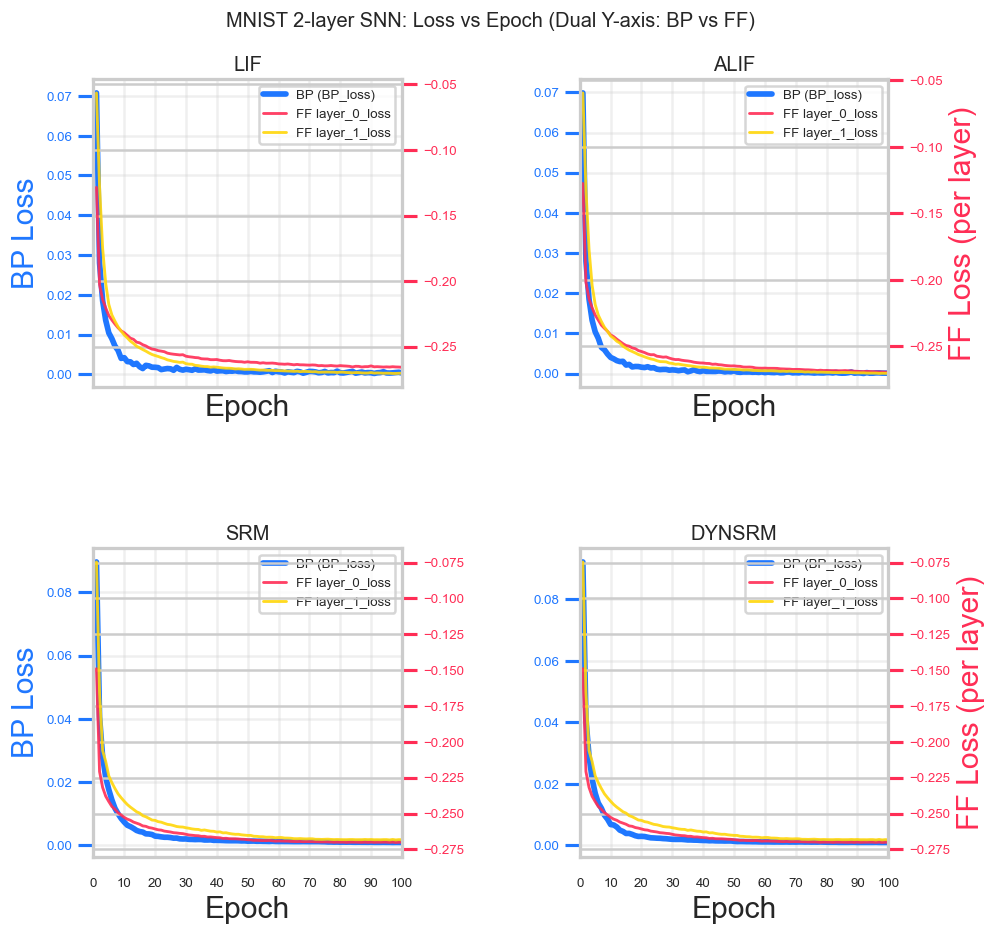

In [11]:
# Loss-vs-epoch comparison: 4 neuron types, BP vs FF (FF shows per-layer losses)
import re


def _sorted_layer_loss_cols(df: pd.DataFrame):
    cols = [c for c in df.columns if re.match(r"^layer_\d+_loss$", c)]
    cols = sorted(cols, key=lambda x: int(re.findall(r"\d+", x)[0]))
    return cols


def _bp_loss_series(df: pd.DataFrame):
    # Prefer explicit BP objective columns.
    for c in ["train_loss", "loss", "total_loss", "test_loss"]:
        if c in df.columns:
            s = df[c].astype(float)
            if np.isfinite(s).any() and not np.allclose(s.values, 0.0):
                return s, c

    # Older BP CSVs may only have FF-style layer loss columns and these are hard-coded to 0.
    layer_cols = _sorted_layer_loss_cols(df)
    if layer_cols:
        s = df[layer_cols].sum(axis=1).astype(float)
        if np.isfinite(s).any() and not np.allclose(s.values, 0.0):
            return s, " + ".join(layer_cols)

    # Fallback proxy to still visualize optimization trend when true loss is missing.
    if "train_acc" in df.columns:
        return (1.0 - df["train_acc"].astype(float)), "BP_loss"

    raise ValueError("BP run has no usable loss columns (and no train_acc for proxy).")


fig, axes = plt.subplots(2, 2, figsize=(8.0, 8.0), sharex=True, sharey=False)
axes = axes.ravel()

# Show only first 100 epochs and use clear 10-epoch major ticks.
x_max = 100
x_ticks = np.arange(0, x_max + 1, 10)

for i, model in enumerate(NEURON_TYPES):
    ax_bp = axes[i]          # left y-axis for BP
    ax_ff = ax_bp.twinx()    # right y-axis for FF per-layer losses

    bp_df = runs[("BP", model)]["data"].copy()
    ff_df = runs[("FF", model)]["data"].copy()

    # Epoch axis fallback in case 'epoch' is missing.
    bp_epoch = bp_df["epoch"].values if "epoch" in bp_df.columns else np.arange(1, len(bp_df) + 1)
    ff_epoch = ff_df["epoch"].values if "epoch" in ff_df.columns else np.arange(1, len(ff_df) + 1)

    # BP loss curve (left axis)
    bp_loss, bp_loss_label = _bp_loss_series(bp_df)
    bp_mask = bp_epoch <= x_max
    bp_line, = ax_bp.plot(bp_epoch[bp_mask], bp_loss.values[bp_mask], lw=3.4, color="#1f77ff", label=f"BP ({bp_loss_label})", zorder=4)

    # FF per-layer loss curves (right axis)
    ff_lines = []
    ff_mask = ff_epoch <= x_max
    ff_layer_cols = _sorted_layer_loss_cols(ff_df)
    if ff_layer_cols:
        ff_palette = ["#ff2d55", "#ffd60a"]  # bright red, bright yellow
        if len(ff_layer_cols) <= len(ff_palette):
            ff_colors = ff_palette[:len(ff_layer_cols)]
        else:
            ff_colors = ff_palette + list(plt.cm.plasma(np.linspace(0.35, 0.95, len(ff_layer_cols) - len(ff_palette))))
        for j, col in enumerate(ff_layer_cols):
            line, = ax_ff.plot(ff_epoch[ff_mask], ff_df[col].astype(float).values[ff_mask], lw=1.7, alpha=0.9, color=ff_colors[j], label=f"FF {col}", zorder=2)
            ff_lines.append(line)
    else:
        # Fallback: if no per-layer loss exists, try a generic loss column.
        for c in ["train_loss", "loss", "total_loss"]:
            if c in ff_df.columns:
                line, = ax_ff.plot(ff_epoch[ff_mask], ff_df[c].astype(float).values[ff_mask], lw=1.7, alpha=0.9, color="#ff2d55", label=f"FF {c}", zorder=2)
                ff_lines.append(line)
                break

    ax_bp.set_title(model.upper(), fontsize=12, pad=5)
    ax_bp.set_xlabel("Epoch")
    ax_bp.set_xlim(0, x_max)
    ax_bp.set_xticks(x_ticks)

    # Keep labels compact: left y-label only on left column, right y-label only on right column.
    if i % 2 == 0:
        ax_bp.set_ylabel("BP Loss", color="#1f77ff")
    else:
        ax_bp.set_ylabel("")
    if i % 2 == 1:
        ax_ff.set_ylabel("FF Loss (per layer)", color="#ff2d55")
    else:
        ax_ff.set_ylabel("")
    ax_bp.tick_params(axis="y", colors="#1f77ff", labelsize=8)
    ax_ff.tick_params(axis="y", colors="#ff2d55", labelsize=8)
    ax_bp.tick_params(axis="x", labelsize=8)
    ax_bp.grid(True, alpha=0.3)
    ax_bp.set_box_aspect(1)

    # Merge legends from both axes.
    handles = [bp_line] + ff_lines
    labels = [h.get_label() for h in handles]
    ax_bp.legend(handles, labels, fontsize=8, frameon=True, loc="best", borderpad=0.3, handlelength=1.7)

fig.suptitle("MNIST 2-layer SNN: Loss vs Epoch (Dual Y-axis: BP vs FF)", fontsize=12, y=0.97)
# Small square subplots with relaxed spacing between panels.
fig.tight_layout(pad=0.45)
fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.09, wspace=0.52, hspace=0.52)

save_path = OUT_DIR / "bp_ff_loss_vs_epoch_by_neuron_dual_axis.png"
fig.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
